In [1]:
"""

LSGAN (Least Squares GAN)
Least Squares Generative Adversarial Networks (Mao et al., 2017)

"""

'\n\nLSGAN (Least Squares GAN) \nLeast Squares Generative Adversarial Networks (Mao et al., 2017)\n\n'

In [2]:
import os

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision

from tqdm import tqdm
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("spandan2/cats-faces-64x64-for-generative-models")

print("Path to dataset files:", path)

100%|██████████| 96.0M/96.0M [00:06<00:00, 14.6MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/spandan2/cats-faces-64x64-for-generative-models/versions/1


In [4]:
# Optimize convolution algorithms for fixed input sizes to boost training speed
torch.backends.cudnn.benchmark = True

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

total_step = 5000
batch_size = 64
latent_size = 100

lr = 0.0002

In [6]:
PRINT_INTERVAL = 25
SAMPLE_INTERVAL = 200
CHECKPOINT_INTERVAL = 1000

sample_dir = "./samples"
checkpoint_dir = "./checkpoints"
os.makedirs(sample_dir, exist_ok=True)
os.makedirs(checkpoint_dir, exist_ok=True)

image shape: torch.Size([64, 3, 32, 32])
dataset size: 15747


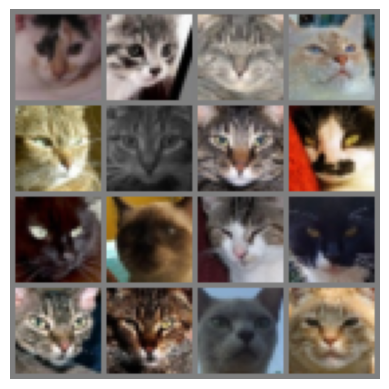

In [7]:
class ImageDataLoader:
    def __init__(self, dataloader):
        self.dataloader = dataloader
        self.iterator = iter(dataloader)

    def __iter__(self):
        return self

    def __next__(self):
        try:
            return next(self.iterator)[0]
        except StopIteration:
            self.iterator = iter(self.dataloader)
            return next(self.iterator)[0]

transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

dataset = datasets.ImageFolder(root=path, transform=transform)
data_loader = DataLoader(
    dataset=dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True
)
train_loader = ImageDataLoader(data_loader)

# Test
images = next(iter(train_loader))
print(f"image shape: {images.shape}")
print(f"dataset size: {len(dataset) // 2}")

images = torchvision.utils.make_grid(images[:16], nrow=4)
images = (images + 1) / 2 # [-1, 1] -> [0, 1]
plt.imshow(images.permute(1, 2, 0))
plt.axis("off")
plt.show()

In [8]:
#################### Generator ####################

class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(latent_size, 256 * 4 * 4),
            nn.Unflatten(1, (256, 4, 4)),

            UpBlock(256, 128), # (B, 256, 4, 4)  -> (B, 128, 8, 8)
            UpBlock(128, 64),  # (B, 128, 8, 8)  -> (B, 64, 16, 16)
            UpBlock(64, 32),   # (B, 64, 16, 16) -> (B, 32, 32, 32)

            nn.Conv2d(32, 3, 3, 1, 1), # (B, 3, 32, 32)
            nn.Tanh()
        )

        self.network.apply(init_weights)

    def forward(self, z):
        return self.network(z)

#################### UpBlock ####################

class UpBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.up = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear'),
            nn.Conv2d(in_channels, out_channels, 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.2)
        )

    def forward(self, x):
        return self.up(x)

In [9]:
#################### Discriminator ####################

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            DownBlock(3, 32, use_norm=False), # 32 -> 16
            DownBlock(32, 64),                # 16 -> 8
            DownBlock(64, 128),               # 8 -> 4

            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 1),
        )

        self.network.apply(init_weights)

    def forward(self, image):
        return self.network(image)

#################### DownBlock ####################

class DownBlock(nn.Module):
    def __init__(self, in_channels, out_channels, use_norm=True):
        super().__init__()

        self.down = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, 2, 1, bias=not use_norm),
            nn.BatchNorm2d(out_channels) if use_norm else nn.Identity(),
            nn.LeakyReLU(0.2)
        )

    def forward(self, x):
        return self.down(x)

In [10]:
def init_weights(m):
    if isinstance(m, torch.nn.Conv2d) or isinstance(m, torch.nn.ConvTranspose2d):
        torch.nn.init.normal_(m.weight, 0.0, 0.02)
    elif isinstance(m, torch.nn.BatchNorm2d):
        torch.nn.init.normal_(m.weight, 1.0, 0.02)
        torch.nn.init.zeros_(m.bias)

In [11]:
def visualize_sample(fixed_z, step):
    generator.eval()
    with torch.no_grad():
        fake_images = generator(fixed_z).cpu()
        fake_images = (fake_images + 1) / 2  # [-1, 1] -> [0, 1]

        grid = torchvision.utils.make_grid(fake_images, nrow=8)
        plt.figure(figsize=(16, 4))
        plt.imshow(grid.permute(1, 2, 0))
        plt.axis("off")
        plt.tight_layout()
        plt.show()

        torchvision.utils.save_image(
            fake_images,
            f"{sample_dir}/step_{step:03d}.png",
            nrow=8
        )
    generator.train()

def save_checkpoint(step):
    torch.save({
        "step": step,
        "generator": generator.state_dict(),
        "discriminator": discriminator.state_dict(),
        "optimizer_G": optimizer_G.state_dict(),
        "optimizer_D": optimizer_D.state_dict(),
    }, f"{checkpoint_dir}/gan_step_{step:03d}.pth")

def load_checkpoint(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)

    generator.load_state_dict(checkpoint["generator"])
    discriminator.load_state_dict(checkpoint["discriminator"])
    optimizer_G.load_state_dict(checkpoint["optimizer_G"])
    optimizer_D.load_state_dict(checkpoint["optimizer_D"])
    start_step = checkpoint["step"]
    print(f"Loaded checkpoint: {checkpoint_path} (step {start_step})")
    return start_step

In [12]:
generator = Generator().to(device)
discriminator = Discriminator().to(device)

criterion = nn.MSELoss()

optimizer_G = optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.99))
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.99))

In [13]:
# if pretrained
# path = "./checkpoints/gan_epoch_1000.pth"
# start_step = load_checkpoint(path)
start_step = 0

D_loss: 0.0977  G_loss: 0.8566  D(x): 0.858  D(G(z)): 0.085:   4%|▍         | 199/5000 [00:12<04:51, 16.48it/s]

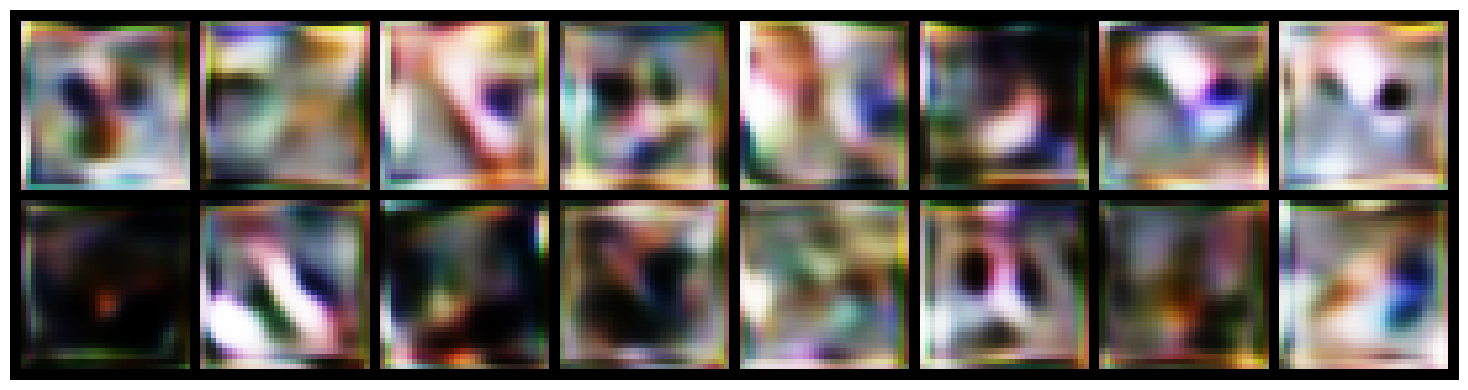

D_loss: 0.2039  G_loss: 0.6877  D(x): 0.739  D(G(z)): 0.188:   8%|▊         | 399/5000 [00:22<03:19, 23.10it/s]

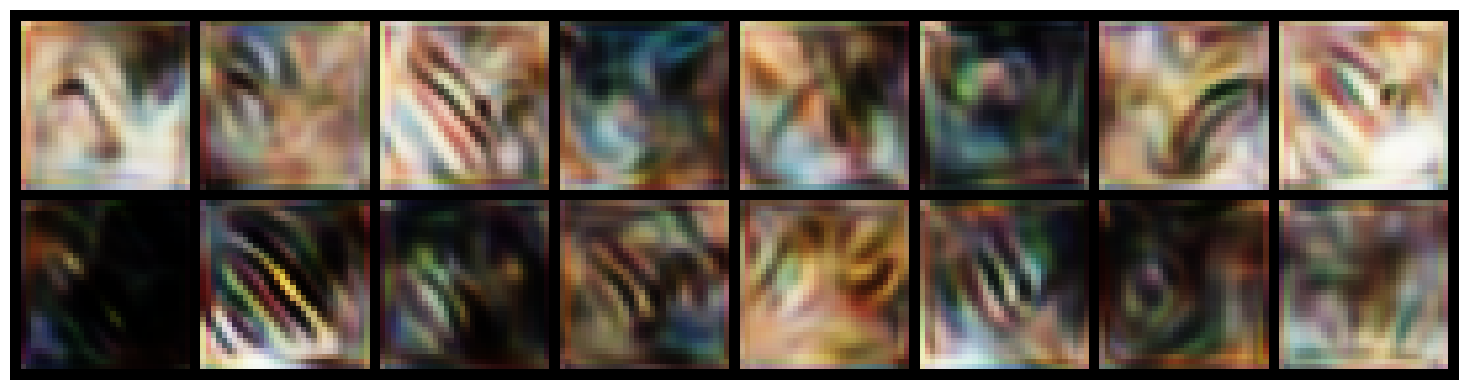

D_loss: 0.1665  G_loss: 0.4913  D(x): 0.745  D(G(z)): 0.324:  12%|█▏        | 598/5000 [00:33<03:15, 22.51it/s]

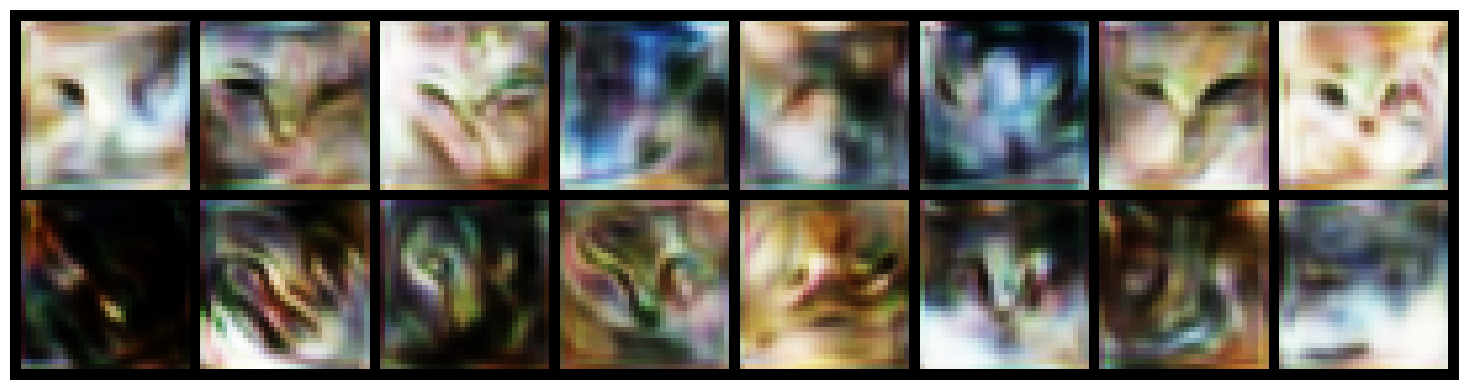

D_loss: 0.1583  G_loss: 0.8436  D(x): 0.914  D(G(z)): 0.101:  16%|█▌        | 799/5000 [00:42<03:20, 20.99it/s] 

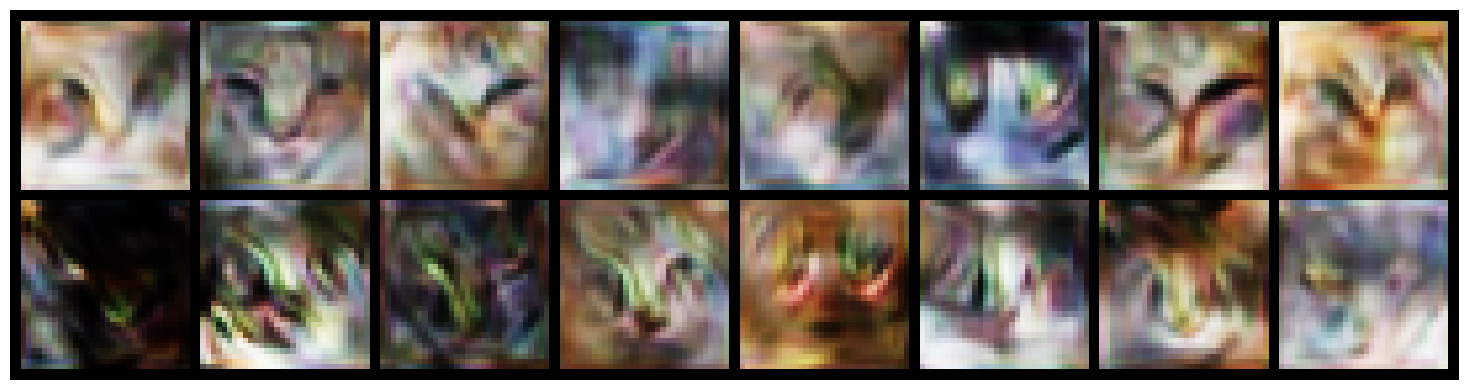

D_loss: 0.1921  G_loss: 0.9548  D(x): 0.850  D(G(z)): 0.047:  20%|█▉        | 998/5000 [00:52<03:45, 17.74it/s] 

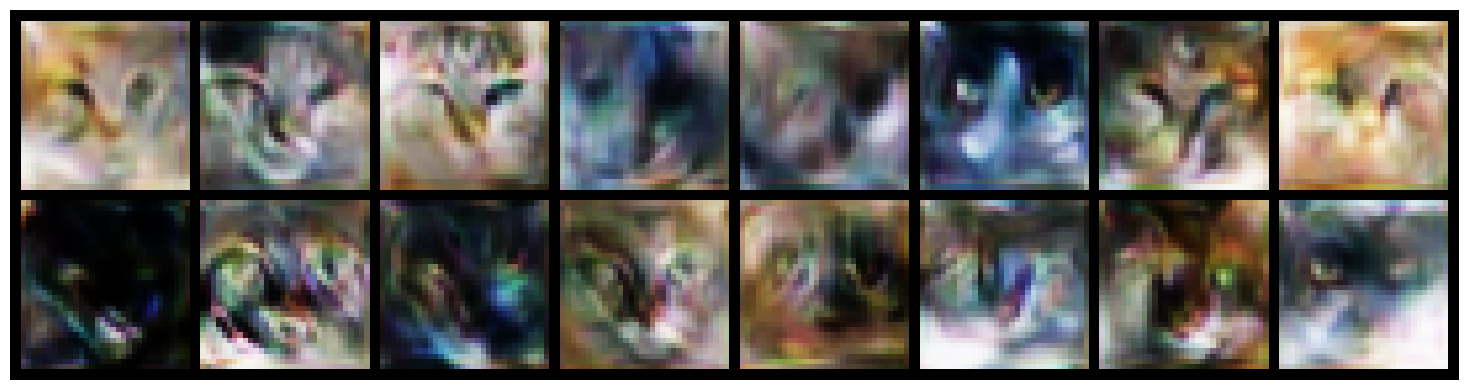

D_loss: 0.1579  G_loss: 0.9206  D(x): 0.940  D(G(z)): 0.062:  24%|██▍       | 1199/5000 [01:02<02:43, 23.26it/s]

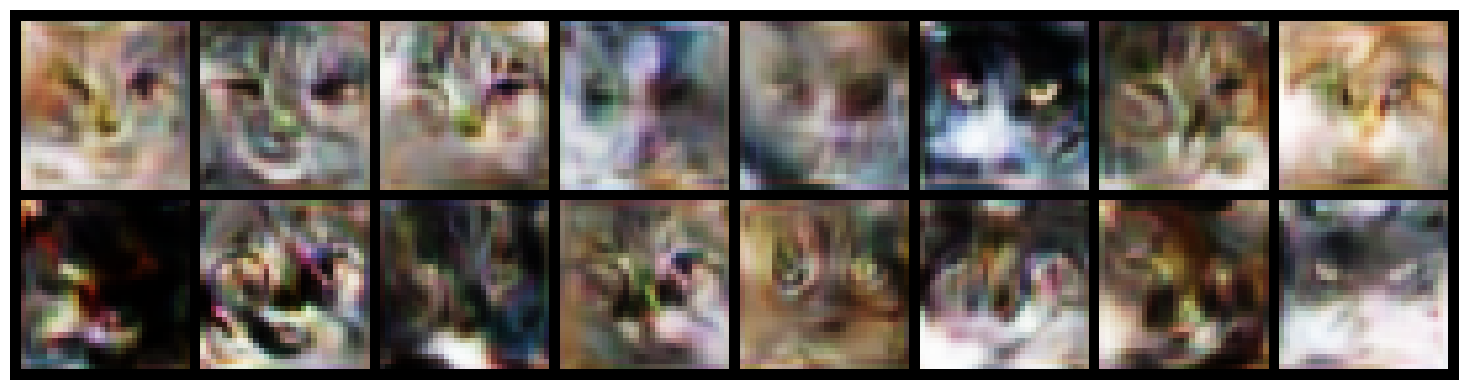

D_loss: 0.2165  G_loss: 0.7991  D(x): 0.799  D(G(z)): 0.124:  28%|██▊       | 1398/5000 [01:12<02:47, 21.54it/s]

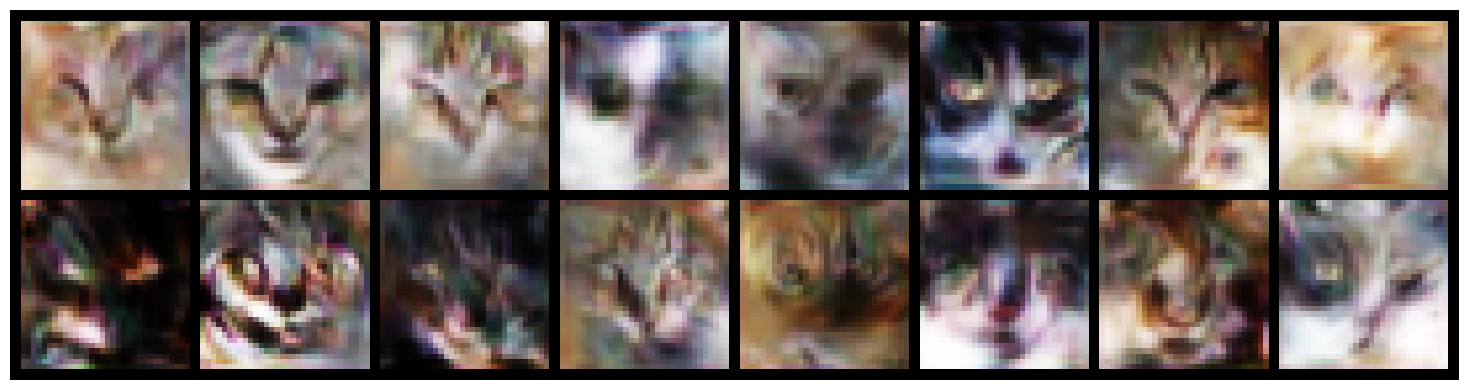

D_loss: 0.1661  G_loss: 0.9476  D(x): 0.919  D(G(z)): 0.049:  32%|███▏      | 1599/5000 [01:22<02:31, 22.43it/s]

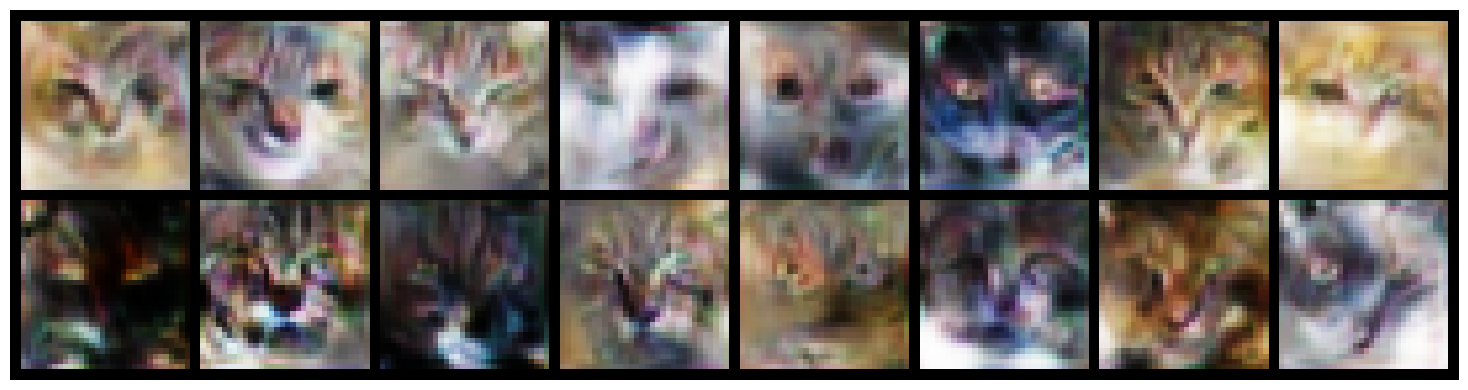

D_loss: 0.1875  G_loss: 0.8173  D(x): 0.790  D(G(z)): 0.118:  36%|███▌      | 1799/5000 [01:32<03:25, 15.56it/s]

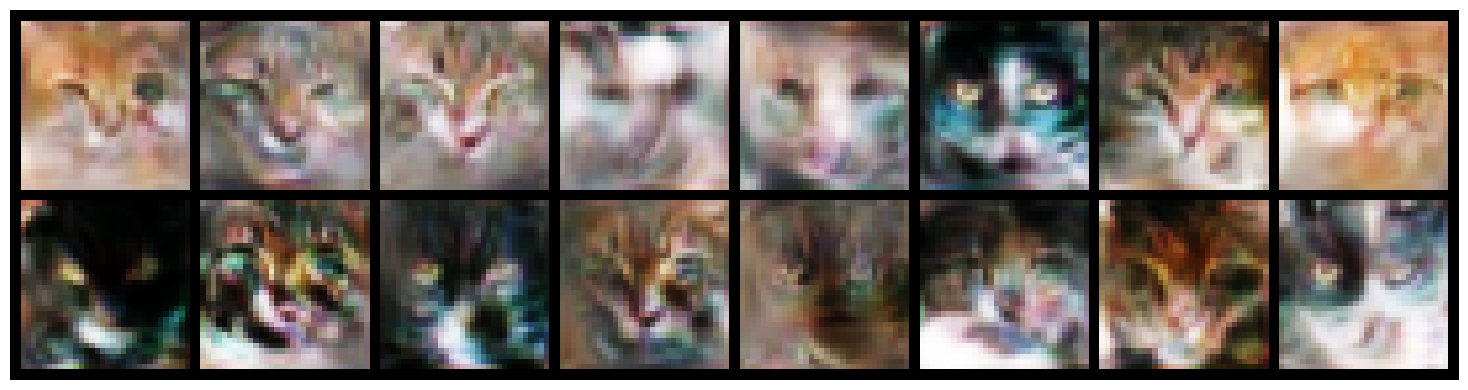

D_loss: 0.2462  G_loss: 0.6053  D(x): 0.714  D(G(z)): 0.261:  40%|███▉      | 1997/5000 [01:41<02:17, 21.79it/s]

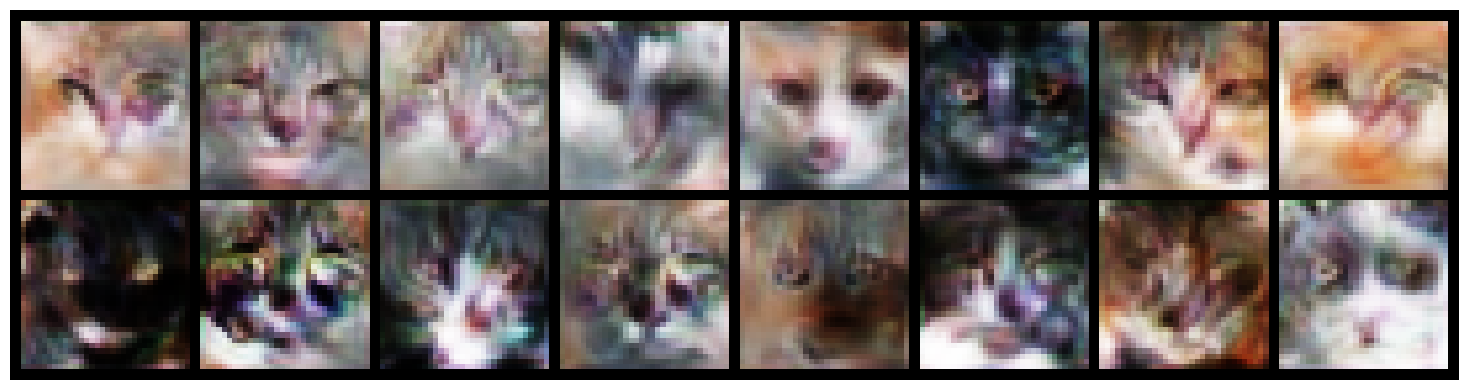

D_loss: 0.3225  G_loss: 0.4376  D(x): 0.539  D(G(z)): 0.362:  44%|████▍     | 2198/5000 [01:51<02:07, 22.00it/s]

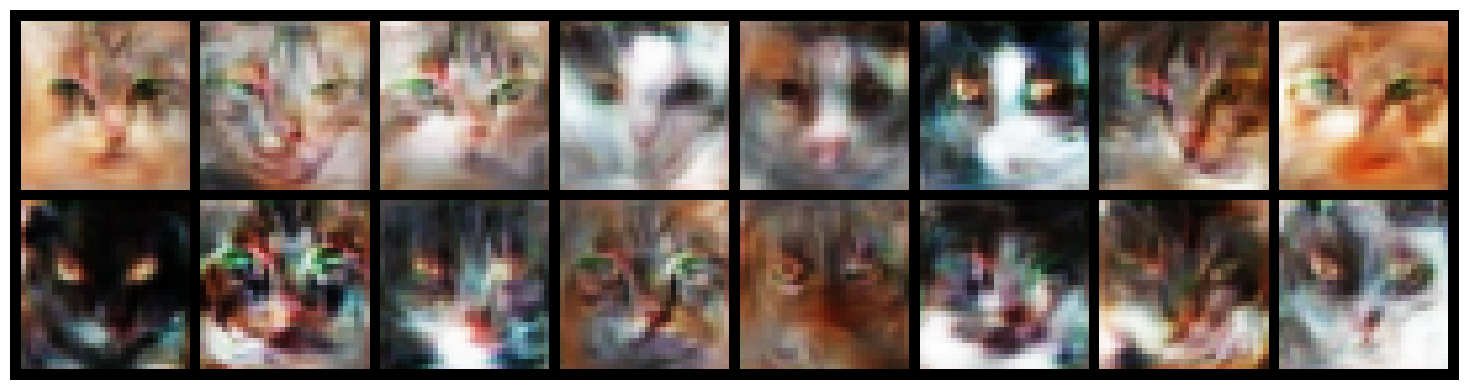

D_loss: 0.3946  G_loss: 0.3238  D(x): 0.531  D(G(z)): 0.460:  48%|████▊     | 2397/5000 [02:01<01:58, 21.88it/s]

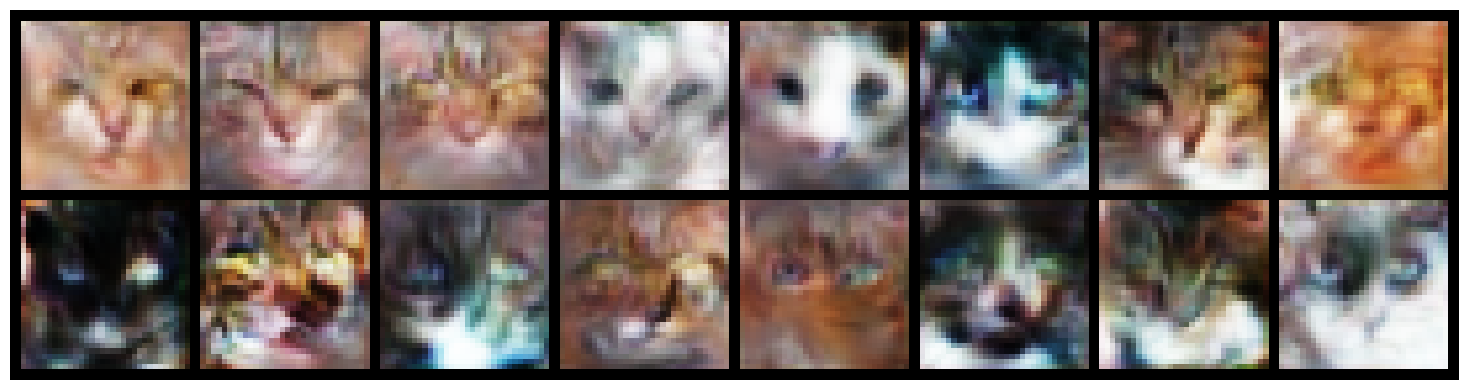

D_loss: 0.1979  G_loss: 0.7149  D(x): 0.681  D(G(z)): 0.181:  52%|█████▏    | 2599/5000 [02:12<01:51, 21.52it/s] 

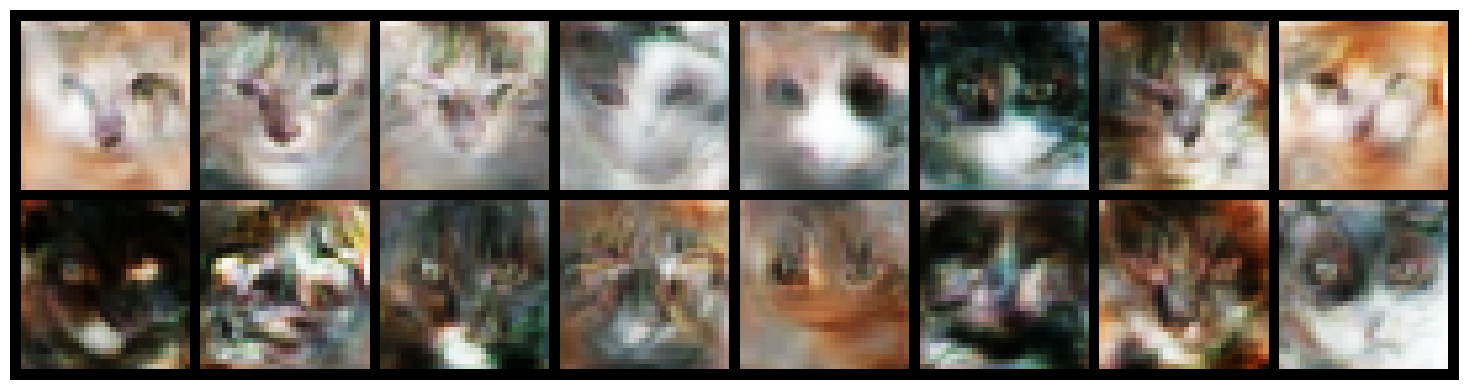

D_loss: 0.2789  G_loss: 0.7908  D(x): 0.870  D(G(z)): 0.133:  56%|█████▌    | 2798/5000 [02:21<02:06, 17.44it/s]

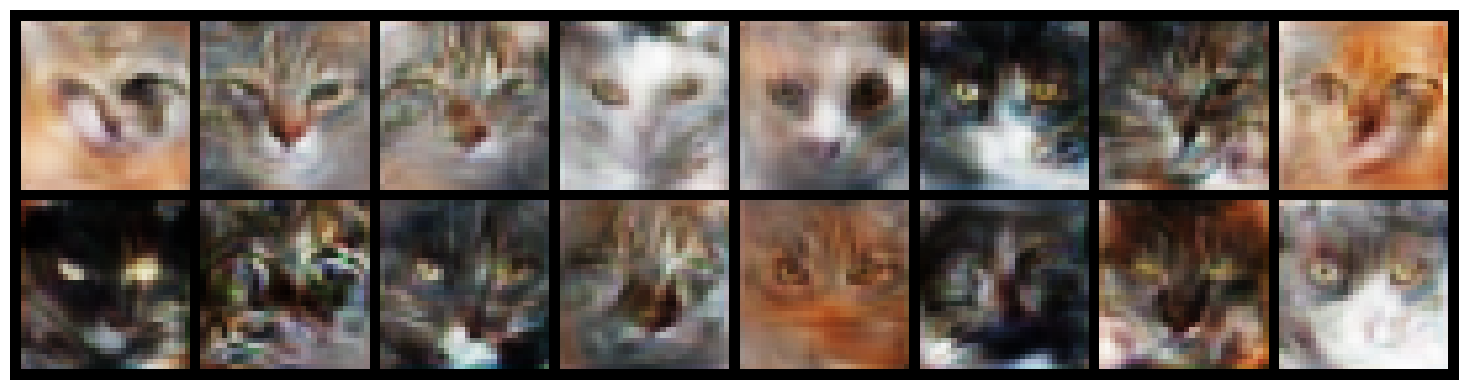

D_loss: 0.2323  G_loss: 0.7492  D(x): 0.777  D(G(z)): 0.166:  60%|█████▉    | 2999/5000 [02:31<01:33, 21.49it/s] 

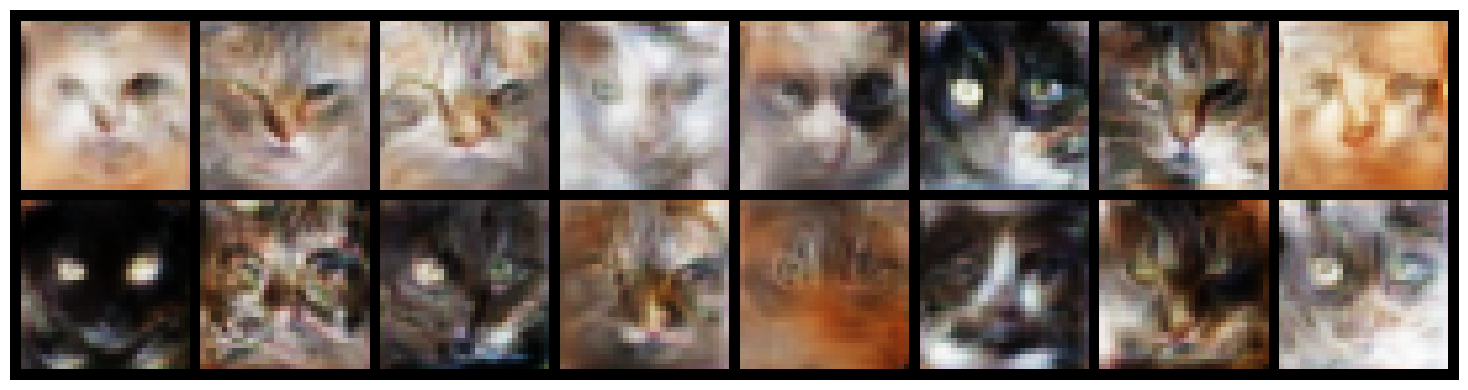

D_loss: 0.2770  G_loss: 0.4418  D(x): 0.556  D(G(z)): 0.369:  64%|██████▍   | 3199/5000 [02:42<01:26, 20.79it/s]

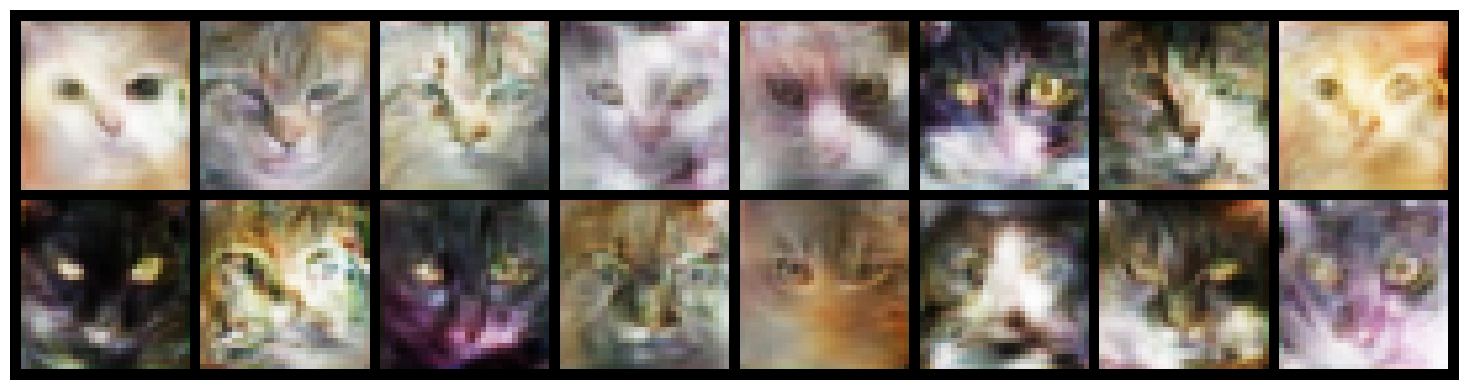

D_loss: 0.3010  G_loss: 1.0199  D(x): 0.797  D(G(z)): 0.019:  68%|██████▊   | 3398/5000 [02:52<01:13, 21.88it/s]

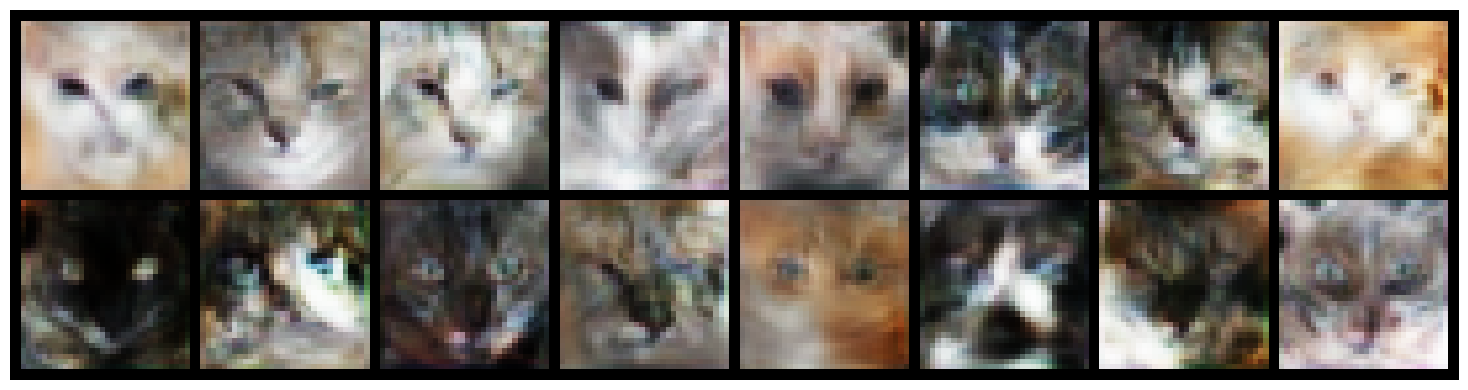

D_loss: 0.2226  G_loss: 0.8365  D(x): 0.966  D(G(z)): 0.105:  72%|███████▏  | 3599/5000 [03:02<01:05, 21.29it/s]

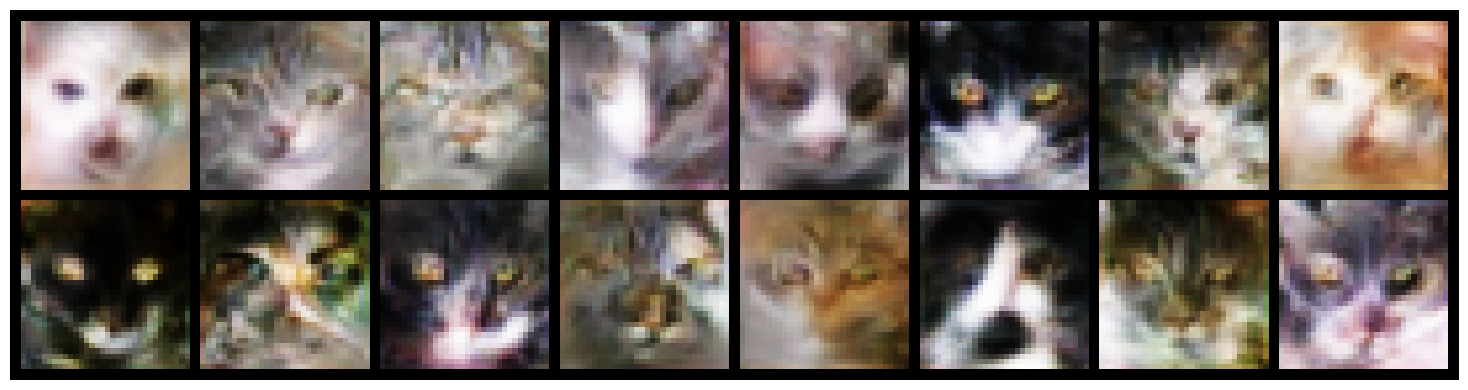

D_loss: 0.1831  G_loss: 0.7936  D(x): 0.771  D(G(z)): 0.141:  76%|███████▌  | 3799/5000 [03:12<01:04, 18.48it/s]

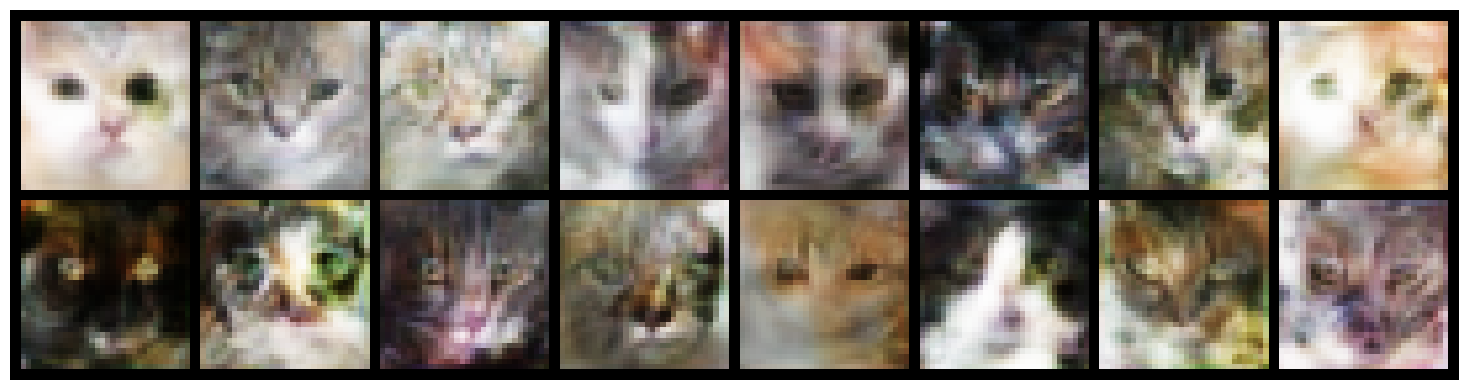

D_loss: 0.2635  G_loss: 1.0353  D(x): 0.982  D(G(z)): 0.014:  80%|███████▉  | 3998/5000 [03:22<00:47, 21.25it/s]

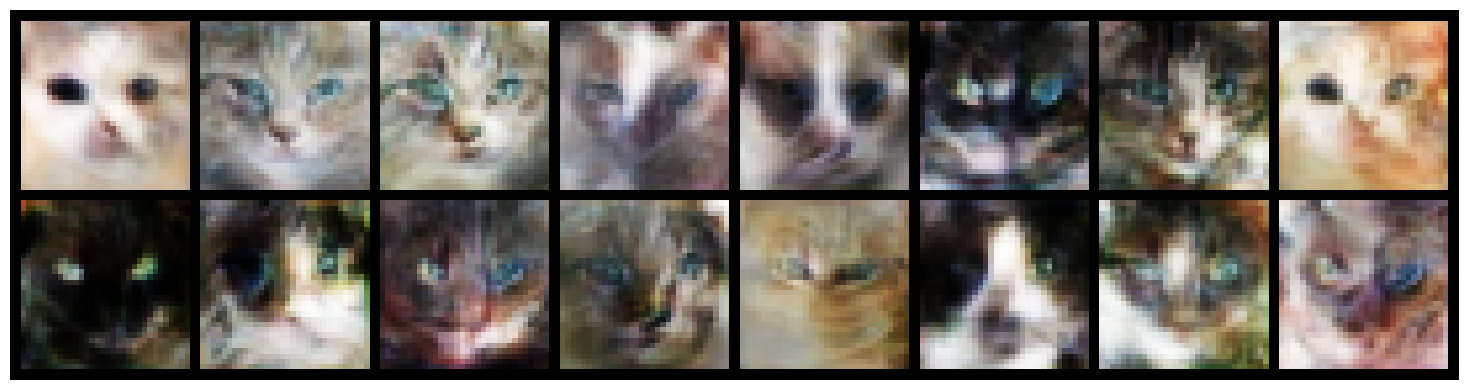

D_loss: 0.1940  G_loss: 0.7319  D(x): 0.840  D(G(z)): 0.176:  84%|████████▍ | 4198/5000 [03:33<00:37, 21.31it/s]

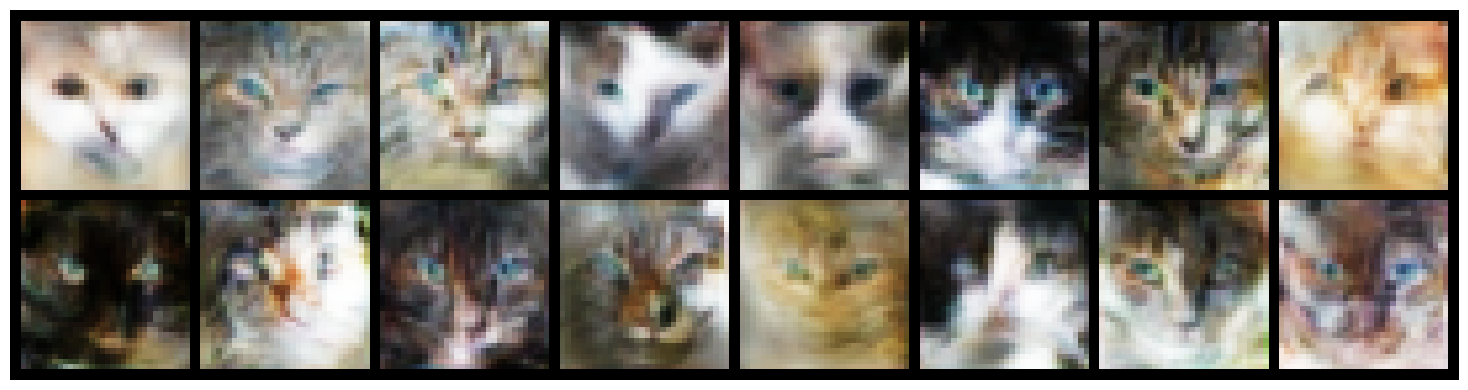

D_loss: 0.2095  G_loss: 0.8018  D(x): 0.658  D(G(z)): 0.134:  88%|████████▊ | 4397/5000 [03:43<00:27, 21.59it/s]

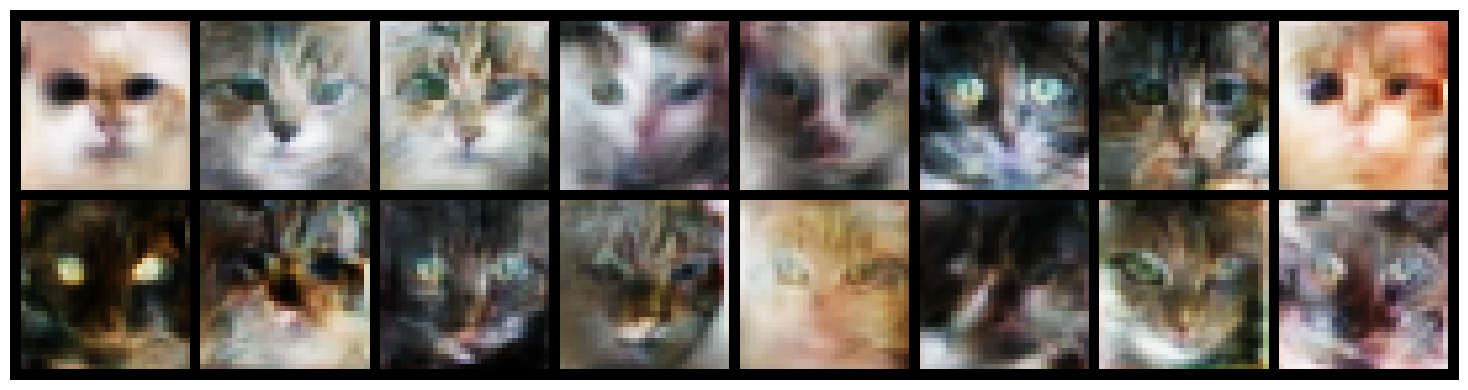

D_loss: 0.2144  G_loss: 0.6182  D(x): 0.678  D(G(z)): 0.238:  92%|█████████▏| 4599/5000 [03:54<00:26, 15.04it/s]

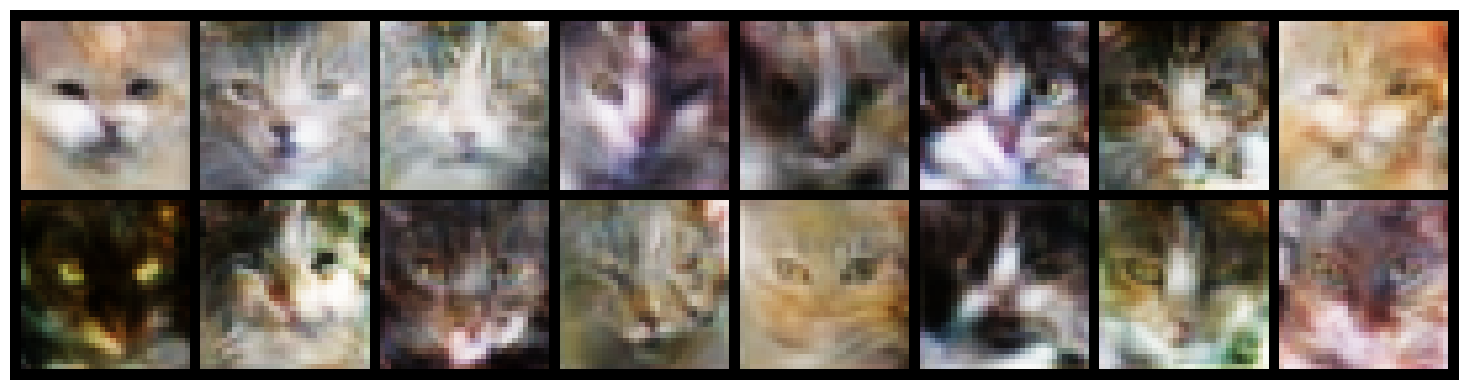

D_loss: 0.2561  G_loss: 1.5801  D(x): 0.980  D(G(z)): -0.231:  96%|█████████▌| 4797/5000 [04:04<00:09, 21.15it/s]

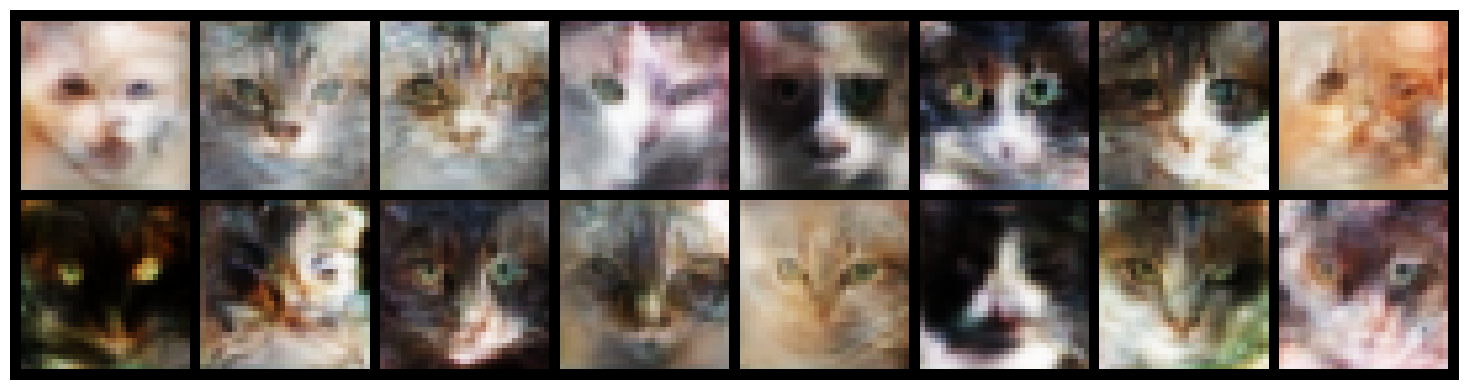

D_loss: 0.1697  G_loss: 0.9913  D(x): 0.886  D(G(z)): 0.038: 100%|█████████▉| 4998/5000 [04:14<00:00, 21.27it/s]

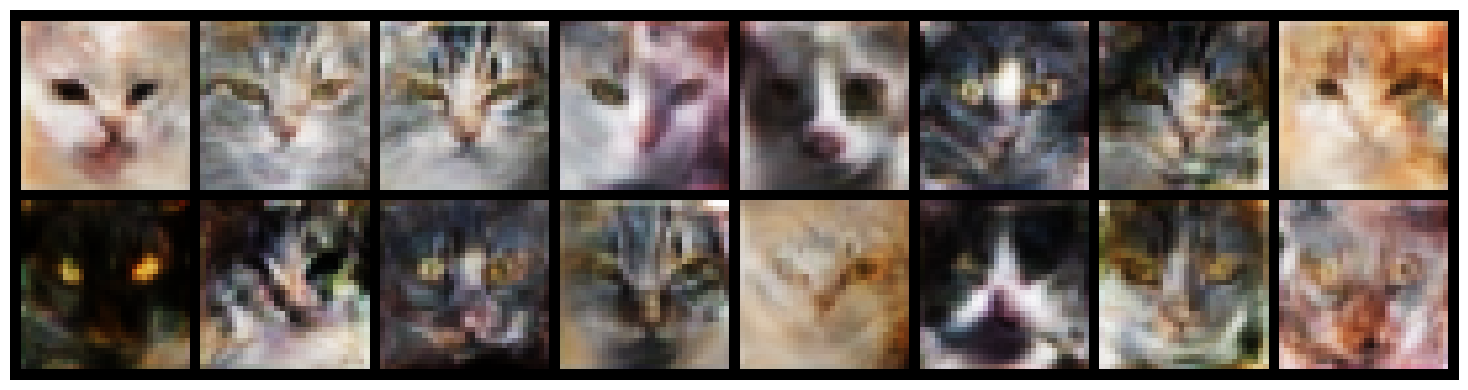

D_loss: 0.1697  G_loss: 0.9913  D(x): 0.886  D(G(z)): 0.038: 100%|██████████| 5000/5000 [04:14<00:00, 19.63it/s]


In [14]:
########## Train ##########

fixed_z_generator = torch.Generator(device=device).manual_seed(42)
fixed_z = torch.randn(16, latent_size, generator=fixed_z_generator, device=device) # for eval
real_targets = torch.ones(batch_size, 1, device=device)  # (b, 1)
fake_targets = torch.zeros(batch_size, 1, device=device) # (b, 1)

pbar = tqdm(range(start_step, total_step), desc="LSGAN")

for step in pbar:
    real_images = next(train_loader).to(device)


    ########## D Train ##########
    z = torch.randn(batch_size, latent_size, device=device)
    with torch.no_grad():
        fake_images = generator(z)

    d_real = discriminator(real_images)
    d_fake = discriminator(fake_images)
    real_loss = criterion(d_real, real_targets)
    fake_loss = criterion(d_fake, fake_targets)

    loss_D = real_loss + fake_loss

    optimizer_D.zero_grad()
    loss_D.backward()
    optimizer_D.step()


    ########## G Train ##########
    z = torch.randn(batch_size, latent_size, device=device)
    fake_images = generator(z)
    d_fake = discriminator(fake_images)
    loss_G = criterion(d_fake, real_targets)

    optimizer_G.zero_grad()
    loss_G.backward()
    optimizer_G.step()


    ########## Log ##########

    if (step + 1) % PRINT_INTERVAL == 0:
        pbar.set_description(
            f"D_loss: {loss_D.item():.4f}  G_loss: {loss_G.item():.4f}  "
            f"D(x): {d_real.mean().item():.3f}  D(G(z)): {d_fake.mean().item():.3f}"
        )

    if (step + 1) % SAMPLE_INTERVAL == 0:
        visualize_sample(fixed_z, step + 1)

    if (step + 1) % CHECKPOINT_INTERVAL == 0:
        save_checkpoint(step + 1)